In [1]:
# Run this cell first (restart runtime after if needed)
!pip install pathway pandas numpy matplotlib bokeh scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.6/777.6 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.6/244.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/6

In [1]:
from google.colab import files
uploaded = files.upload()  # Upload cleaned_dataset.csv

Saving cleaned_dataset.csv to cleaned_dataset (1).csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_dataset.csv", parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(df.shape)
print(df.dtypes)
print(df.head())
print(df["SystemCodeNumber"].unique())
print(df.isnull().sum())

(18368, 10)
Timestamp            datetime64[ns]
SystemCodeNumber             object
Capacity                      int64
Occupancy                     int64
QueueLength                   int64
TrafficLevel                  int64
IsSpecialDay                  int64
VehicleTypeWeight           float64
Latitude                    float64
Longitude                   float64
dtype: object
            Timestamp  SystemCodeNumber  Capacity  Occupancy  QueueLength  \
0 2016-10-04 07:59:00       BHMBCCMKT01       577         61            1   
1 2016-10-04 07:59:00    Others-CCCPS98      3103        588            2   
2 2016-10-04 07:59:00   Others-CCCPS202      2937        547            2   
3 2016-10-04 07:59:00  Others-CCCPS135a      3883       1081            2   
4 2016-10-04 07:59:00  Others-CCCPS119a      2803        195            1   

   TrafficLevel  IsSpecialDay  VehicleTypeWeight   Latitude  Longitude  
0             0             0                1.0  26.144536  91.736172  
1    

In [3]:
df["OccupancyRate"] = df["Occupancy"] / df["Capacity"]
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Date"] = df["Timestamp"].dt.date

# Encode traffic and special day as numeric (already 0/1)
# Add lag feature per lot (previous occupancy rate)
df = df.sort_values(["SystemCodeNumber", "Timestamp"])
df["PrevOccupancyRate"] = df.groupby("SystemCodeNumber")["OccupancyRate"].shift(1)
df["PrevOccupancyRate"] = df["PrevOccupancyRate"].fillna(df["OccupancyRate"])

print(df[["Timestamp","SystemCodeNumber","OccupancyRate","Hour","DayOfWeek"]].head(10))

              Timestamp SystemCodeNumber  OccupancyRate  Hour  DayOfWeek
0   2016-10-04 07:59:00      BHMBCCMKT01       0.105719     7          1
15  2016-10-04 08:25:00      BHMBCCMKT01       0.110919     8          1
32  2016-10-04 08:59:00      BHMBCCMKT01       0.138648     8          1
46  2016-10-04 09:32:00      BHMBCCMKT01       0.185442     9          1
58  2016-10-04 09:59:00      BHMBCCMKT01       0.259965     9          1
79  2016-10-04 10:26:00      BHMBCCMKT01       0.306759    10          1
88  2016-10-04 10:59:00      BHMBCCMKT01       0.379549    10          1
109 2016-10-04 11:25:00      BHMBCCMKT01       0.428076    11          1
123 2016-10-04 11:59:00      BHMBCCMKT01       0.448873    11          1
136 2016-10-04 12:29:00      BHMBCCMKT01       0.461005    12          1


In [4]:
BASE_PRICE = 10.0   # base price in currency units
MIN_PRICE  = 5.0
MAX_PRICE  = 50.0

def dynamic_price(occupancy_rate, queue_length, traffic_level, is_special_day, vehicle_weight):
    """
    Pricing model:
      - Occupancy drives the primary multiplier (exponential surge at high load)
      - Queue length adds urgency premium
      - Traffic level adds congestion premium
      - Special day adds flat premium
      - Vehicle weight adjusts for vehicle type
    """
    # Occupancy multiplier: 1x at 0%, surges past 80%
    occ_multiplier = 1 + 2.0 * (occupancy_rate ** 2)

    # Queue premium: each queued car adds 5% to base
    queue_premium = 1 + 0.05 * queue_length

    # Traffic premium
    traffic_premium = 1 + 0.10 * traffic_level

    # Special day flat addition
    special_premium = 1.15 if is_special_day else 1.0

    price = (BASE_PRICE
             * occ_multiplier
             * queue_premium
             * traffic_premium
             * special_premium
             * vehicle_weight)

    return round(np.clip(price, MIN_PRICE, MAX_PRICE), 2)

# Apply to full dataset
df["DynamicPrice"] = df.apply(lambda r: dynamic_price(
    r["OccupancyRate"], r["QueueLength"],
    r["TrafficLevel"], r["IsSpecialDay"], r["VehicleTypeWeight"]
), axis=1)

print(df[["Timestamp","SystemCodeNumber","OccupancyRate","DynamicPrice"]].head(15))

              Timestamp SystemCodeNumber  OccupancyRate  DynamicPrice
0   2016-10-04 07:59:00      BHMBCCMKT01       0.105719         10.73
15  2016-10-04 08:25:00      BHMBCCMKT01       0.110919         10.76
32  2016-10-04 08:59:00      BHMBCCMKT01       0.138648         11.42
46  2016-10-04 09:32:00      BHMBCCMKT01       0.185442         11.76
58  2016-10-04 09:59:00      BHMBCCMKT01       0.259965          8.74
79  2016-10-04 10:26:00      BHMBCCMKT01       0.306759         13.66
88  2016-10-04 10:59:00      BHMBCCMKT01       0.379549         30.14
109 2016-10-04 11:25:00      BHMBCCMKT01       0.428076         18.79
123 2016-10-04 11:59:00      BHMBCCMKT01       0.448873          9.65
136 2016-10-04 12:29:00      BHMBCCMKT01       0.461005         16.76
152 2016-10-04 13:02:00      BHMBCCMKT01       0.466205         23.24
164 2016-10-04 13:29:00      BHMBCCMKT01       0.455806         22.93
173 2016-10-04 14:02:00      BHMBCCMKT01       0.412478         20.10
189 2016-10-04 14:29

In [5]:
import pathway as pw
import time, threading

# ── Schema matching our CSV columns ──────────────────────────────────────────
class ParkingSchema(pw.Schema):
    Timestamp         : str
    SystemCodeNumber  : str
    Capacity          : int
    Occupancy         : int
    QueueLength       : int
    TrafficLevel      : int
    IsSpecialDay      : int
    VehicleTypeWeight : float
    Latitude          : float
    Longitude         : float

# ── Read as a static CSV (Pathway treats it as a stream) ─────────────────────
parking_data = pw.io.csv.read(
    "./cleaned_dataset.csv",
    schema=ParkingSchema,
    mode="static",           # use "streaming" for live file append simulation
)

# ── Compute occupancy rate ────────────────────────────────────────────────────
parking_with_rate = parking_data.select(
    *pw.this,
    OccupancyRate = pw.this.Occupancy / pw.this.Capacity,
)

# ── Apply dynamic pricing using pw.apply ─────────────────────────────────────
def price_row(occ_rate, queue, traffic, special, weight):
    occ_mul   = 1 + 2.0 * (occ_rate ** 2)
    q_mul     = 1 + 0.05 * queue
    t_mul     = 1 + 0.10 * traffic
    s_mul     = 1.15 if special else 1.0
    price     = BASE_PRICE * occ_mul * q_mul * t_mul * s_mul * weight
    return round(float(np.clip(price, MIN_PRICE, MAX_PRICE)), 2)

priced_stream = parking_with_rate.select(
    *pw.this,
    DynamicPrice = pw.apply(
        price_row,
        pw.this.OccupancyRate,
        pw.this.QueueLength,
        pw.this.TrafficLevel,
        pw.this.IsSpecialDay,
        pw.this.VehicleTypeWeight,
    )
)

# ── Write results to CSV ──────────────────────────────────────────────────────
pw.io.csv.write(priced_stream, "./pathway_priced_output.csv")

# ── Run Pathway pipeline ──────────────────────────────────────────────────────
pw.run()
print("Pathway pipeline complete. Output saved to pathway_priced_output.csv")

Output()

/usr/local/lib/python3.12/dist-packages/beartype/_util/hint/pep/utilpeptest.py:311: BeartypeDecorHintPep585DeprecationWarning: PEP 484 type hint typing.Iterable[pathway.internals.expression.ColumnReference] deprecated by PEP 585. This hint is scheduled for removal in the first Python version released after October 5th, 2025. To resolve this, import this hint from "beartype.typing" rather than "typing". For further commentary and alternatives, see also:
    https://beartype.readthedocs.io/en/latest/api_roar/#pep-585-deprecations
  warn(


Pathway pipeline complete. Output saved to pathway_priced_output.csv


In [6]:
result_df = pd.read_csv("pathway_priced_output.csv")
print(result_df.shape)
print(result_df[["Timestamp","SystemCodeNumber","OccupancyRate","DynamicPrice"]].head(20))

(18368, 14)
              Timestamp  SystemCodeNumber  OccupancyRate  DynamicPrice
0   2016-10-22 07:59:00  Others-CCCPS119a       0.024973          7.71
1   2016-10-26 09:26:00       BHMBCCTHL01       0.558140         30.80
2   2016-11-17 16:31:00       BHMBCCMKT01       0.197574         11.86
3   2016-10-18 10:28:00    Others-CCCPS98       0.381888         10.85
4   2016-10-19 09:58:00      Broad Street       0.873913         22.38
5   2016-11-05 12:06:00  Others-CCCPS119a       0.134142         17.40
6   2016-11-01 16:00:00       BHMBCCTHL01       0.635659         19.89
7   2016-10-13 11:31:00  Others-CCCPS105a       0.643604         31.82
8   2016-11-09 14:27:00    Others-CCCPS98       0.404125          9.12
9   2016-10-06 10:03:00       BHMBCCMKT01       0.233969         12.76
10  2016-10-10 14:57:00       BHMBCCTHL01       0.692506         12.93
11  2016-10-06 15:31:00      Broad Street       0.860870         28.55
12  2016-11-05 08:26:00       BHMMBMMBX01       0.372635         

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Use the preprocessed df from Step 4
feature_cols = ["Hour", "DayOfWeek", "OccupancyRate", "PrevOccupancyRate",
                "QueueLength", "TrafficLevel", "IsSpecialDay", "VehicleTypeWeight"]
target_col   = "OccupancyRate"

lot_models = {}
lot_maes   = {}

for lot, grp in df.groupby("SystemCodeNumber"):
    grp = grp.sort_values("Timestamp").dropna(subset=feature_cols + [target_col])
    if len(grp) < 20:
        continue

    # Shift target: predict NEXT occupancy rate
    grp = grp.copy()
    grp["FutureOccRate"] = grp["OccupancyRate"].shift(-1)
    grp = grp.dropna(subset=["FutureOccRate"])

    X = grp[feature_cols]
    y = grp["FutureOccRate"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)

    lot_models[lot] = model
    lot_maes[lot]   = mae
    print(f"{lot:30s}  MAE: {mae:.4f}")

print(f"\nModels trained for {len(lot_models)} lots.")

BHMBCCMKT01                     MAE: 0.0242
BHMBCCTHL01                     MAE: 0.0390
BHMEURBRD01                     MAE: 0.0271
BHMMBMMBX01                     MAE: 0.0269
BHMNCPHST01                     MAE: 0.0239
BHMNCPNST01                     MAE: 0.0201
Broad Street                    MAE: 0.0228
Others-CCCPS105a                MAE: 0.0239
Others-CCCPS119a                MAE: 0.0224
Others-CCCPS135a                MAE: 0.0151
Others-CCCPS202                 MAE: 0.0128
Others-CCCPS8                   MAE: 0.0230
Others-CCCPS98                  MAE: 0.0139
Shopping                        MAE: 0.0169

Models trained for 14 lots.


In [8]:
forecast_rows = []

for lot, grp in df.groupby("SystemCodeNumber"):
    if lot not in lot_models:
        continue
    grp = grp.sort_values("Timestamp").copy()
    grp = grp.dropna(subset=feature_cols)
    model = lot_models[lot]

    grp["ForecastedOccRate"] = model.predict(grp[feature_cols])
    grp["ForecastedOccRate"] = grp["ForecastedOccRate"].clip(0, 1)

    grp["ForecastedPrice"] = grp.apply(lambda r: dynamic_price(
        r["ForecastedOccRate"], r["QueueLength"],
        r["TrafficLevel"], r["IsSpecialDay"], r["VehicleTypeWeight"]
    ), axis=1)

    forecast_rows.append(grp)

forecast_df = pd.concat(forecast_rows).sort_values(["SystemCodeNumber", "Timestamp"])
print(forecast_df[["Timestamp","SystemCodeNumber","OccupancyRate",
                    "ForecastedOccRate","DynamicPrice","ForecastedPrice"]].head(20))

              Timestamp SystemCodeNumber  OccupancyRate  ForecastedOccRate  \
0   2016-10-04 07:59:00      BHMBCCMKT01       0.105719           0.117504   
15  2016-10-04 08:25:00      BHMBCCMKT01       0.110919           0.133206   
32  2016-10-04 08:59:00      BHMBCCMKT01       0.138648           0.188146   
46  2016-10-04 09:32:00      BHMBCCMKT01       0.185442           0.249688   
58  2016-10-04 09:59:00      BHMBCCMKT01       0.259965           0.305061   
79  2016-10-04 10:26:00      BHMBCCMKT01       0.306759           0.371993   
88  2016-10-04 10:59:00      BHMBCCMKT01       0.379549           0.421958   
109 2016-10-04 11:25:00      BHMBCCMKT01       0.428076           0.445442   
123 2016-10-04 11:59:00      BHMBCCMKT01       0.448873           0.463795   
136 2016-10-04 12:29:00      BHMBCCMKT01       0.461005           0.459445   
152 2016-10-04 13:02:00      BHMBCCMKT01       0.466205           0.450867   
164 2016-10-04 13:29:00      BHMBCCMKT01       0.455806         

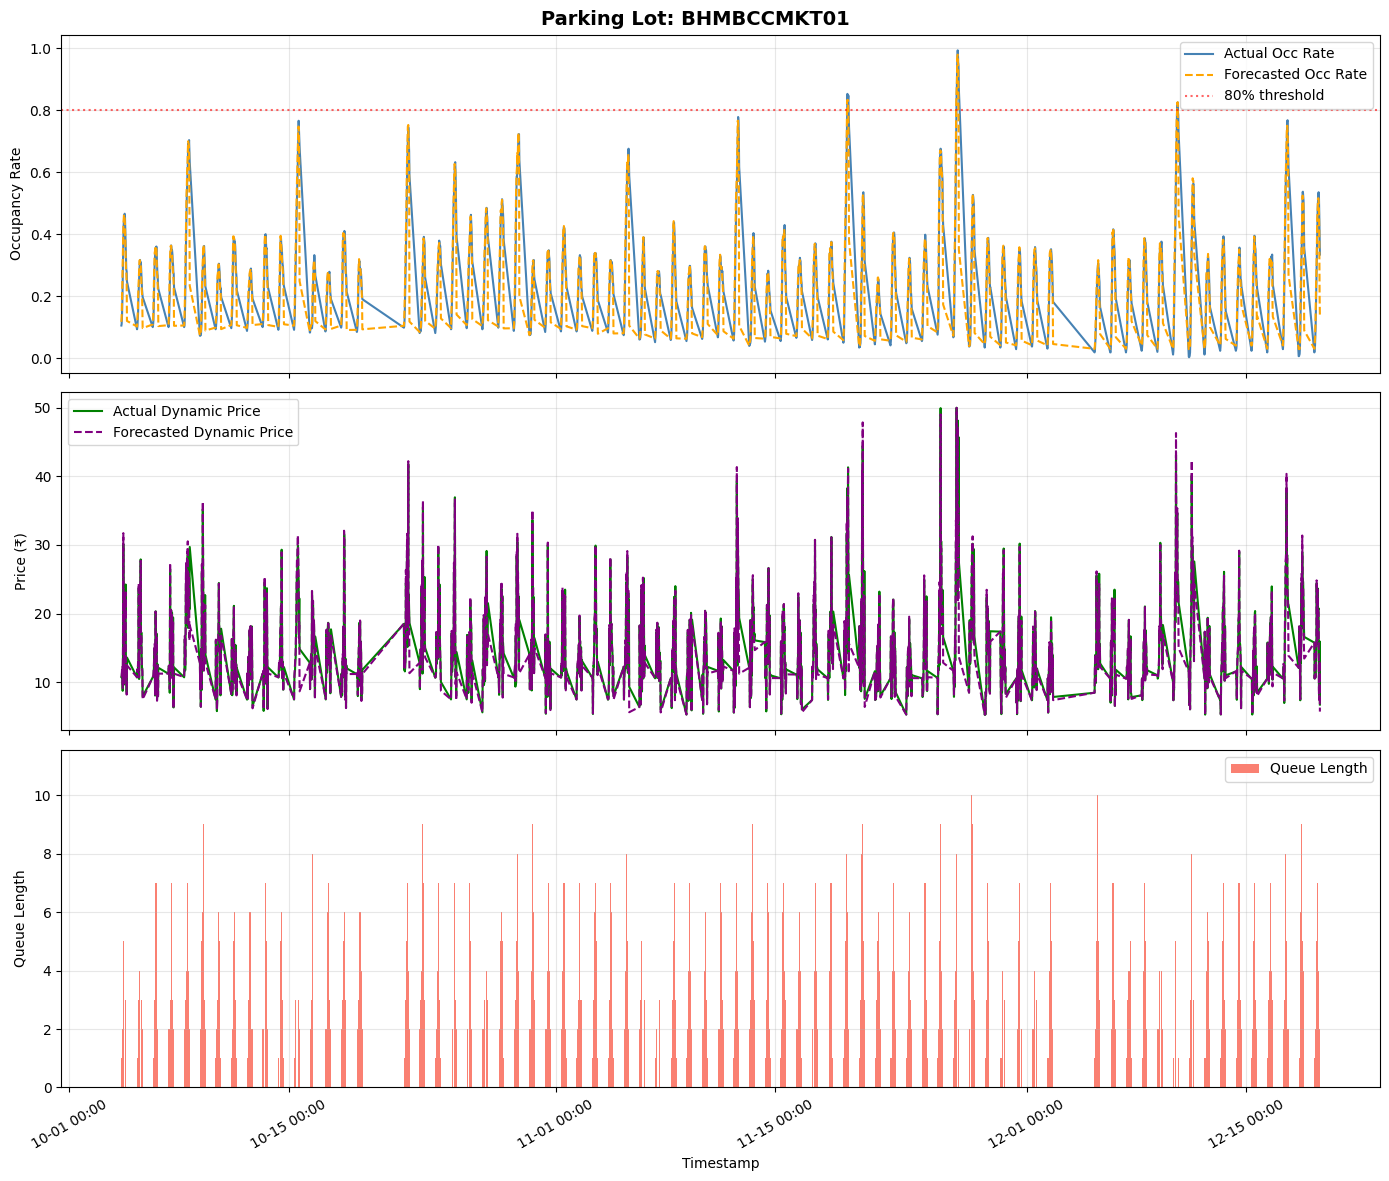

Dashboard saved.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick one lot to visualize
LOT = df["SystemCodeNumber"].value_counts().index[0]
lot_df = forecast_df[forecast_df["SystemCodeNumber"] == LOT].copy()
lot_df["Timestamp"] = pd.to_datetime(lot_df["Timestamp"])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Parking Lot: {LOT}", fontsize=14, fontweight="bold")

# 1. Occupancy Rate
ax1 = axes[0]
ax1.plot(lot_df["Timestamp"], lot_df["OccupancyRate"],    label="Actual Occ Rate",    color="steelblue")
ax1.plot(lot_df["Timestamp"], lot_df["ForecastedOccRate"],label="Forecasted Occ Rate", color="orange", linestyle="--")
ax1.axhline(0.8, color="red", linestyle=":", alpha=0.6, label="80% threshold")
ax1.set_ylabel("Occupancy Rate")
ax1.legend(); ax1.grid(alpha=0.3)

# 2. Dynamic Price
ax2 = axes[1]
ax2.plot(lot_df["Timestamp"], lot_df["DynamicPrice"],     label="Actual Dynamic Price",     color="green")
ax2.plot(lot_df["Timestamp"], lot_df["ForecastedPrice"],  label="Forecasted Dynamic Price",  color="purple", linestyle="--")
ax2.set_ylabel("Price (₹)")
ax2.legend(); ax2.grid(alpha=0.3)

# 3. Queue Length
ax3 = axes[2]
ax3.bar(lot_df["Timestamp"], lot_df["QueueLength"], color="salmon", width=0.02, label="Queue Length")
ax3.set_ylabel("Queue Length")
ax3.set_xlabel("Timestamp")
ax3.legend(); ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("parking_dashboard.png", dpi=150)
plt.show()
print("Dashboard saved.")

In [10]:
import pathway as pw
import threading, time, os, shutil

# Prepare streaming input file
STREAM_FILE = "./live_parking_stream.csv"
shutil.copy("cleaned_dataset.csv", STREAM_FILE)

# Truncate to header only first
with open(STREAM_FILE, "r") as f:
    header = f.readline()
with open(STREAM_FILE, "w") as f:
    f.write(header)

OUTPUT_FILE = "./live_output.csv"

# ── Pathway pipeline in streaming mode ───────────────────────────────────────
class ParkingSchema(pw.Schema):
    Timestamp         : str
    SystemCodeNumber  : str
    Capacity          : int
    Occupancy         : int
    QueueLength       : int
    TrafficLevel      : int
    IsSpecialDay      : int
    VehicleTypeWeight : float
    Latitude          : float
    Longitude         : float

live_data = pw.io.csv.read(STREAM_FILE, schema=ParkingSchema, mode="streaming")

live_priced = live_data.select(
    *pw.this,
    OccupancyRate = pw.this.Occupancy / pw.this.Capacity,
).select(
    *pw.this,
    DynamicPrice = pw.apply(
        price_row,
        pw.this.OccupancyRate,
        pw.this.QueueLength,
        pw.this.TrafficLevel,
        pw.this.IsSpecialDay,
        pw.this.VehicleTypeWeight,
    )
)

pw.io.csv.write(live_priced, OUTPUT_FILE)

# ── Thread: feed rows slowly to simulate real-time data ──────────────────────
source_df = pd.read_csv("cleaned_dataset.csv")

def stream_rows():
    with open(STREAM_FILE, "a") as f:
        for i, row in source_df.iterrows():
            f.write(",".join(str(v) for v in row.values) + "\n")
            f.flush()
            time.sleep(0.05)   # 50ms between rows  ← adjust as needed
            if i > 200:        # stop after 200 rows for demo
                break
    print("Streaming complete.")

feeder = threading.Thread(target=stream_rows, daemon=True)
feeder.start()

# ── Run Pathway (blocks until you interrupt or streaming ends) ────────────────
pw.run()

Output()

Streaming complete.

KeyboardInterrupt: 

In [11]:
summary = forecast_df.groupby("SystemCodeNumber").agg(
    AvgOccupancyRate  = ("OccupancyRate",  "mean"),
    AvgDynamicPrice   = ("DynamicPrice",   "mean"),
    MaxDynamicPrice   = ("DynamicPrice",   "max"),
    AvgForecastedOcc  = ("ForecastedOccRate", "mean"),
    MAE               = ("SystemCodeNumber", lambda x: lot_maes.get(x.iloc[0], float("nan")))
).round(4).reset_index()

print(summary.to_string(index=False))
summary.to_csv("parking_summary.csv", index=False)
print("\nSaved to parking_summary.csv")

SystemCodeNumber  AvgOccupancyRate  AvgDynamicPrice  MaxDynamicPrice  AvgForecastedOcc    MAE
     BHMBCCMKT01            0.2808          15.2514            50.00            0.2810 0.0242
     BHMBCCTHL01            0.7451          27.9823            50.00            0.7424 0.0390
     BHMEURBRD01            0.6436          25.1774            50.00            0.6434 0.0271
     BHMMBMMBX01            0.6948          26.3228            50.00            0.6939 0.0269
     BHMNCPHST01            0.4647          19.4377            50.00            0.4652 0.0239
     BHMNCPNST01            0.5896          21.7193            50.00            0.5903 0.0201
    Broad Street            0.6321          24.7250            50.00            0.6321 0.0228
Others-CCCPS105a            0.5667          22.4266            50.00            0.5670 0.0239
Others-CCCPS119a            0.1927          13.9566            38.09            0.1892 0.0224
Others-CCCPS135a            0.5904          24.2554         

In [12]:
import pathway as pw
import threading, time, os, shutil, pandas as pd

# ── Prep files ────────────────────────────────────────────────────────────────
STREAM_FILE = "./live_parking_stream.csv"
OUTPUT_FILE = "./live_output.csv"

source_df = pd.read_csv("cleaned_dataset.csv")

# Write only the header first
with open(STREAM_FILE, "w") as f:
    f.write(",".join(source_df.columns) + "\n")

if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)

# ── Pathway schema ────────────────────────────────────────────────────────────
class ParkingSchema(pw.Schema):
    Timestamp         : str
    SystemCodeNumber  : str
    Capacity          : int
    Occupancy         : int
    QueueLength       : int
    TrafficLevel      : int
    IsSpecialDay      : int
    VehicleTypeWeight : float
    Latitude          : float
    Longitude         : float

# ── Build pipeline ────────────────────────────────────────────────────────────
live_data = pw.io.csv.read(STREAM_FILE, schema=ParkingSchema, mode="streaming")

live_priced = live_data.select(
    *pw.this,
    OccupancyRate = pw.this.Occupancy / pw.this.Capacity,
).select(
    *pw.this,
    DynamicPrice = pw.apply(
        price_row,   # defined in Step 5
        pw.this.OccupancyRate,
        pw.this.QueueLength,
        pw.this.TrafficLevel,
        pw.this.IsSpecialDay,
        pw.this.VehicleTypeWeight,
    )
)

pw.io.csv.write(live_priced, OUTPUT_FILE)

# ── Row feeder: streams N rows then stops ─────────────────────────────────────
N_ROWS    = 100     # ← change this to stream more rows
ROW_DELAY = 0.1     # ← seconds between rows (0.1 = fast enough to see results)

def stream_rows():
    with open(STREAM_FILE, "a") as f:
        for i, row in source_df.head(N_ROWS).iterrows():
            f.write(",".join(str(v) for v in row.values) + "\n")
            f.flush()
            time.sleep(ROW_DELAY)
    print(f"✅ Done feeding {N_ROWS} rows.")

feeder = threading.Thread(target=stream_rows, daemon=True)

# ── Pathway runner: auto-stops after feeder finishes + buffer time ────────────
PATHWAY_TIMEOUT = N_ROWS * ROW_DELAY + 5   # seconds

def run_pathway():
    pw.run(terminate_on_error=False)

pathway_thread = threading.Thread(target=run_pathway, daemon=True)

# ── Start both ────────────────────────────────────────────────────────────────
print("🚀 Starting Pathway pipeline...")
pathway_thread.start()
feeder.start()

feeder.join()                      # wait for all rows to be fed
time.sleep(3)                      # give Pathway a moment to flush output
print("🏁 Streaming done. Reading output...")

# ── Read and show results ─────────────────────────────────────────────────────
if os.path.exists(OUTPUT_FILE):
    live_result = pd.read_csv(OUTPUT_FILE)
    print(f"Rows processed: {len(live_result)}")
    print(live_result[["Timestamp","SystemCodeNumber","OccupancyRate","DynamicPrice"]].head(20))
else:
    print("⚠️ Output file not found yet — try increasing the sleep above.")

Output()

🚀 Starting Pathway pipeline...


✅ Done feeding 100 rows.

🏁 Streaming done. Reading output...

ParserError: Error tokenizing data. C error: Expected 14 fields in line 12, saw 27
